In [18]:
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

from huggingface_hub import hf_hub_download
import torch, open_clip
from PIL import Image
from IPython.display import display

In [2]:
for model_name in ['RN50']:
    checkpoint_path = hf_hub_download("chendelong/RemoteCLIP", f"RemoteCLIP-{model_name}.pt", cache_dir='checkpoints')
    print(f'{model_name} is downloaded to {checkpoint_path}.')

RN50 is downloaded to checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-RN50.pt.


In [5]:
model_name = 'RN50' # 'RN50' or 'ViT-B-32' or 'ViT-L-14'
model, _, preprocess = open_clip.create_model_and_transforms(model_name)
tokenizer = open_clip.get_tokenizer(model_name)

path_to_your_checkpoints = 'checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38'

ckpt = torch.load(f"{path_to_your_checkpoints}/RemoteCLIP-{model_name}.pt", map_location="cpu")
message = model.load_state_dict(ckpt)
print("message", message)
model = model.cuda().eval()

message <All keys matched successfully>


In [45]:
label_root = "/home/koger/pronghorn-processing"
label_root = "/mnt/c/Users/benko/Dropbox/UWyo/pronghorn-census"
herd_unit = "PR529"
image_root = f"/mnt/h/Pronghorn Vertical Imagery/2024/{herd_unit}"

image_paths = sorted(glob.glob(os.path.join(image_root, "*.JPG")))


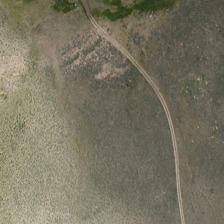

In [29]:
image = Image.open(image_paths[5]) # 0, 5

image_size = 224

new_size = (image_size, image_size)  # Example: resize to 300 pixels wide and 200 pixels high

# Resize the image
resized_img = image.resize(new_size)
display(resized_img)

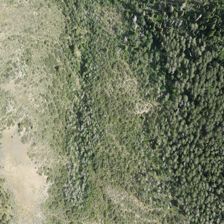

Predictions of RN50:
sagebrush steppe                          16.0%
a waste land                               2.1%
forest                                    50.0%
pine forest                               15.7%
grassland                                  0.9%
green grass                                0.0%
agricultural fields                        0.0%
lake                                       0.0%
rocky                                     15.3%


In [ ]:
text_queries = [

    "sagebrush steppe",
    "a waste land",
    # "a dirt road",
    "forest",
    "pine forest",
    "grassland",
    "green grass",
    "agricultural fields",
    "lake",
    "rocky",
    # "dirt road"
    ]

image_ind = -1

text = tokenizer(text_queries)
image = Image.open(image_paths[image_ind])

image_size = 224
new_size = (image_size, image_size)
# Resize the image
resized_img = image.resize(new_size)
display(resized_img)

image = preprocess(resized_img).unsqueeze(0)

with torch.no_grad(), torch.cuda.amp.autocast():
    image_features = model.encode_image(image.cuda())
    text_features = model.encode_text(text.cuda())
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1).cpu().numpy()[0]

print(f'Predictions of {model_name}:')
for query, prob in zip(text_queries, text_probs):
    print(f"{query:<40} {prob * 100:5.1f}%")

In [89]:
images = []
embeddings = []

for image_file in image_paths:
    image = Image.open(image_file)

    image_size = 224
    new_size = (image_size, image_size)
    # Resize the image
    resized_img = image.resize(new_size)
    images.append(resized_img)

    image = preprocess(resized_img).unsqueeze(0)

    with torch.no_grad(), torch.cuda.amp.autocast():
        image_features = model.encode_image(image.cuda())
        image_features /= image_features.norm(dim=-1, keepdim=True)
    embeddings.append(image_features.cpu().numpy())
embeddings = np.vstack(embeddings)

In [60]:
embeddings.shape

(95, 1024)

In [67]:
from sklearn.manifold import TSNE
from sklearn.neighbors import BallTree


In [125]:
tsne_embedding = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=30).fit_transform(embeddings)
tsne_embedding.shape

(948, 2)

In [127]:
tree = BallTree(tsne_embedding, leaf_size=2)

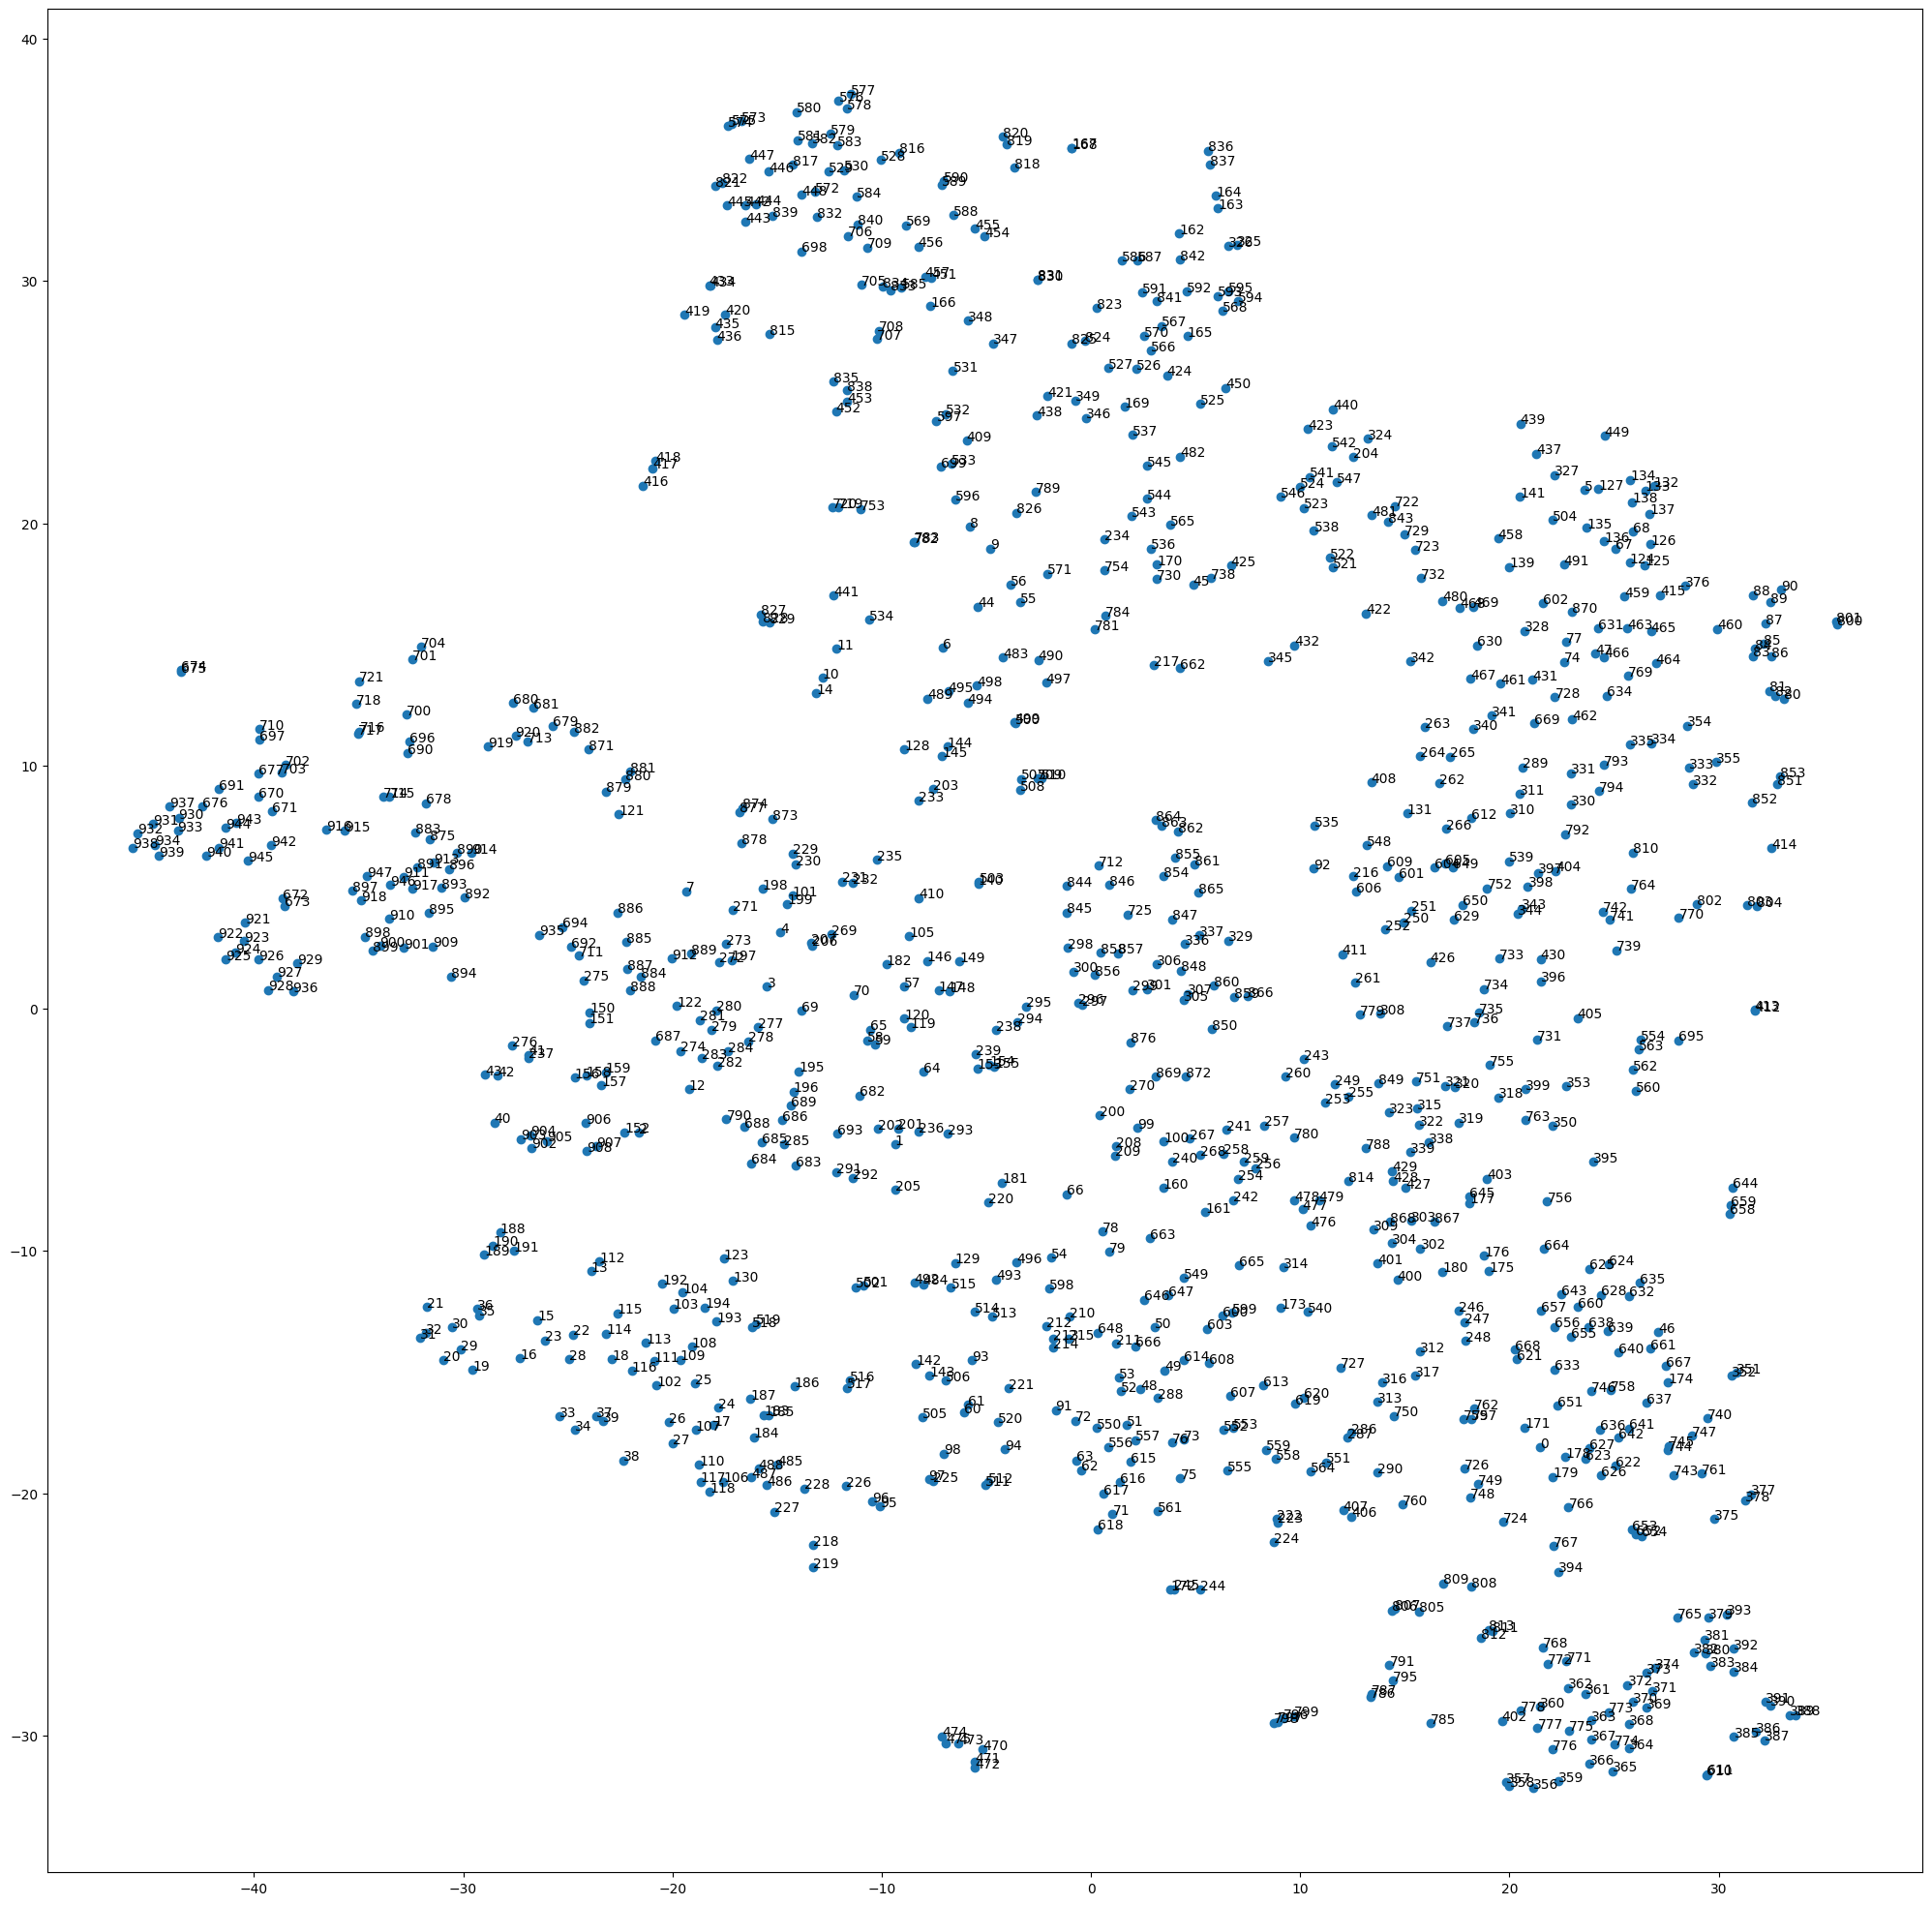

In [192]:
plt.figure(figsize=(25,25))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1])
for i in range(len(tsne_embedding)):
    plt.annotate(str(i), (tsne_embedding[i, 0], tsne_embedding[i, 1]))

In [221]:
out_folder  = "/mnt/c/Users/benko/Dropbox/UWyo/pronghorn-census/figures"
os.makedirs(out_folder, exist_ok=True)

In [ ]:
932 #847 #116 #718 #837 #930 #528 #385 #49 #83

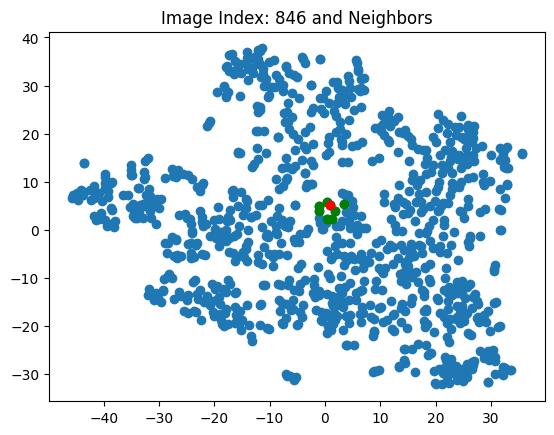

In [251]:
im_id = 846
neighbors = 8
dist, inds = tree.query([tsne_embedding[im_id]], k=neighbors)

plt.figure()
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1])
plt.scatter(tsne_embedding[inds[0], 0], tsne_embedding[inds[0], 1], color='green')
plt.scatter(tsne_embedding[im_id, 0], tsne_embedding[im_id, 1], color='red')
plt.title(f'Image Index: {im_id} and Neighbors')

plt.savefig(os.path.join(out_folder, f'embedding_{im_id}.png'), dpi=300, bbox_inches='tight')



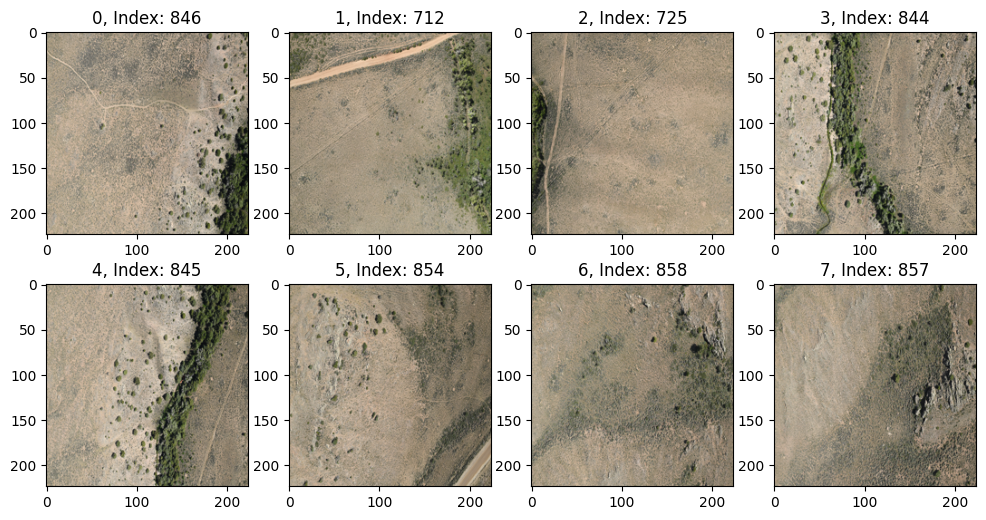

In [252]:
fig, axs = plt.subplots(2, neighbors//2, figsize=(12,6))

for rank, (ind, ax) in enumerate(zip(inds[0], axs.flatten())):
    ax.set_title(f'{rank}, Index: {ind}')
    ax.imshow(images[ind])

fig.savefig(os.path.join(out_folder, f'embedding_neighbors_{im_id}.png'), dpi=300, bbox_inches='tight')

In [215]:
detection_model = "06-18-2025-18-43-48-with-gts"
scores_files = sorted(
    glob.glob(os.path.join(label_root, detection_model, f"{herd_unit.lower()}*scores*.npy"))
    )
labels_files = sorted(
    glob.glob(os.path.join(label_root, detection_model, f"{herd_unit.lower()}*_labels*.npy"))
    )
gt_labels_files = sorted(
    glob.glob(os.path.join(label_root, detection_model, f"{herd_unit.lower()}*gtlabels*.npy"))
    )

In [216]:
gt_labels = []
scores = []
for gt_label_file in gt_labels_files:
    name = gt_label_file.split("_gtlabels")[0]
    scores_file = name + "_scores.npy"
    gt_labels.append(np.load(gt_label_file))
    scores.append(np.load(scores_file))

In [135]:
len(gt_labels), len(tsne_embedding)

(948, 948)

In [136]:
pronghorn_scores = []
false_positive_scores = []
uncertain_scores = []
for im_labels, im_scores in zip(gt_labels, scores):
    uncertain_scores.append(im_scores[(im_labels == 1) | (im_labels == 4)])
uncertain_scores = np.concatenate(uncertain_scores)

for im_labels, im_scores in zip(gt_labels, scores):
    false_positive_scores.append(im_scores[im_labels == 0])
false_positive_scores = np.concatenate(false_positive_scores)
for im_labels, im_scores in zip(gt_labels, scores):
    pronghorn_scores.append(im_scores[im_labels == 2])
pronghorn_scores = np.concatenate(pronghorn_scores)
print(f"{len(pronghorn_scores)} pronghorn found")
pronghorn_scores.sort()

131 pronghorn found


In [137]:
len(pronghorn_scores)

131

In [209]:
ph_mean_scores = []
ph_num = []
fp_num = []
precision = []
recall = []
f1 = []

score_threshold = 0.7

for im_labels, im_scores in zip(gt_labels, scores):
    ph_mean_scores.append(np.mean(im_scores[im_labels == 2]))
    ph_num.append(np.sum(im_labels == 2))
    fp_num.append(np.sum(im_labels == 0))

    TP = np.sum((im_labels == 2) & (im_scores > score_threshold))
    FP = np.sum((im_labels == 0) & (im_scores > score_threshold))
    FN = np.sum((im_labels == 2) & (im_scores <= score_threshold))
    if (TP + FP) == 0:
        precision.append(np.nan)
    else:
        precision.append((TP) / (TP + FP))
           
    if TP + FN == 0:
        recall.append(np.nan)
    else:
        recall.append((TP) / (TP + FN))

    if (precision[-1] is np.nan) or (recall[-1] is np.nan):
        f1.append(np.nan)
    else:
        f1.append(2 * (precision[-1] * recall[-1]) / (precision[-1] + recall[-1]))

ph_num = np.array(ph_num)
fp_num = np.array(fp_num)
# pronghorn_scores = np.concatenate(pronghorn_scores)

/home/koger/environments/orthocounting/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/koger/environments/orthocounting/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [165]:
plt.style.use('default')

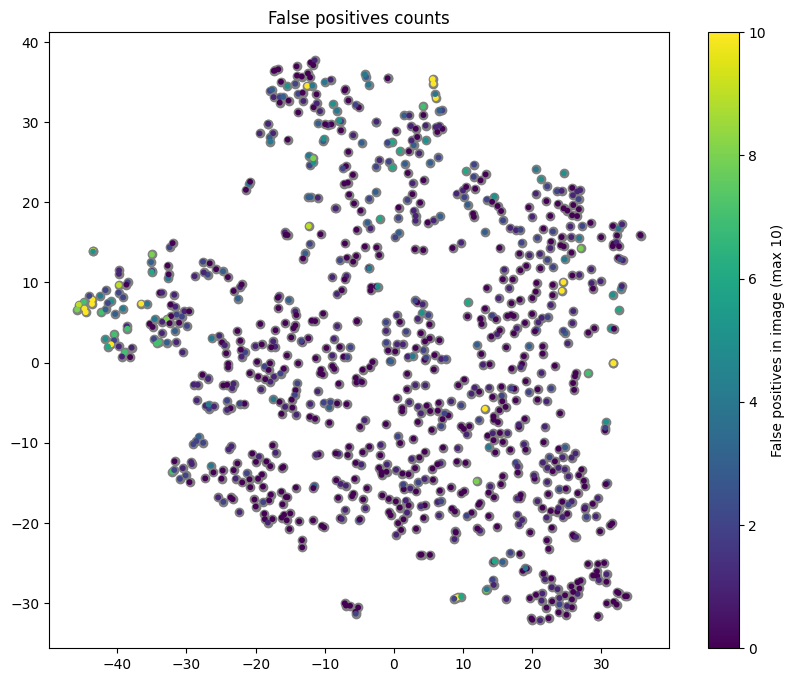

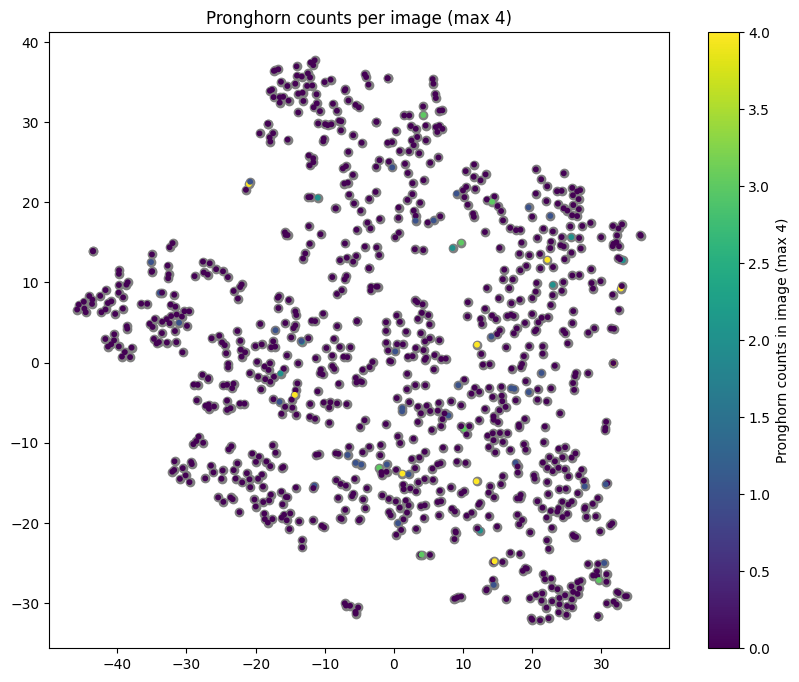

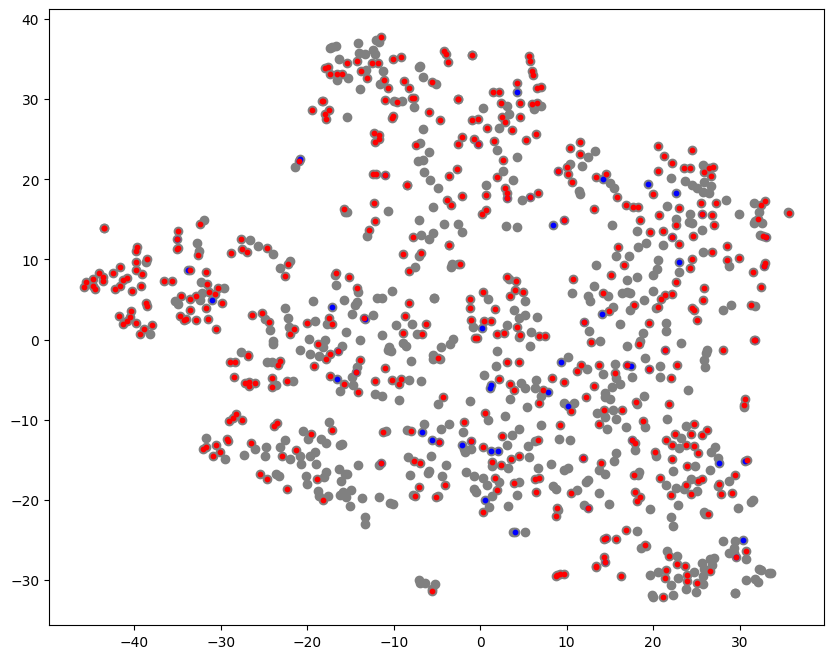

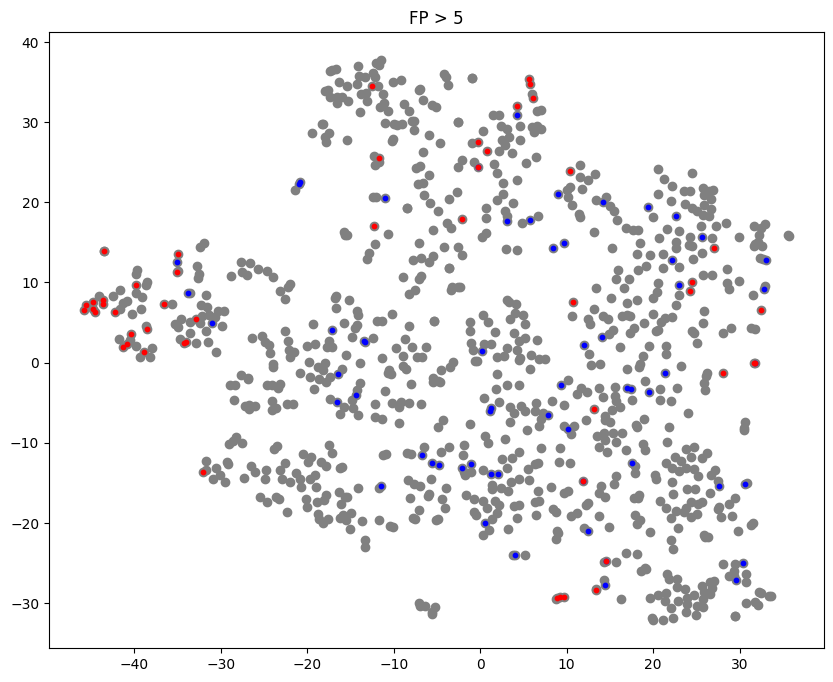

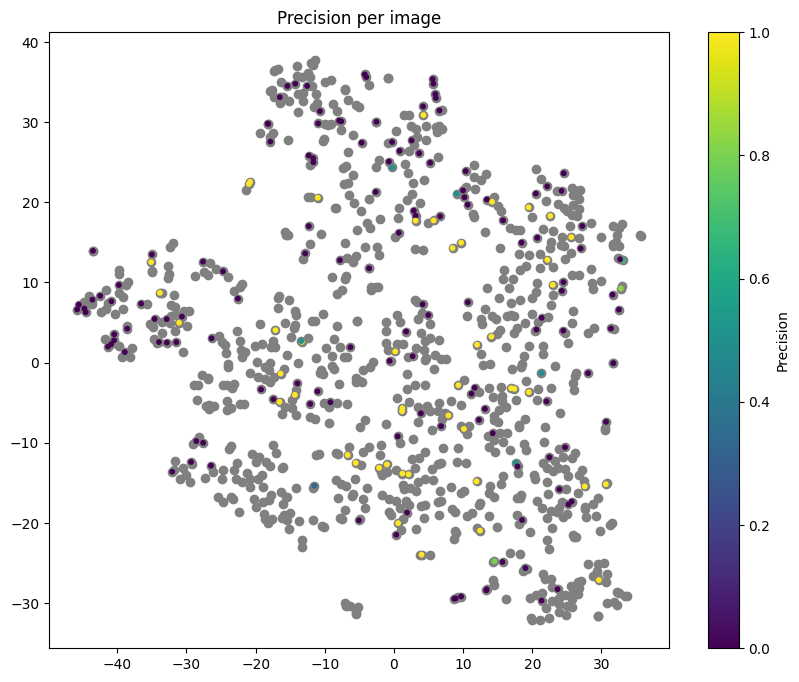

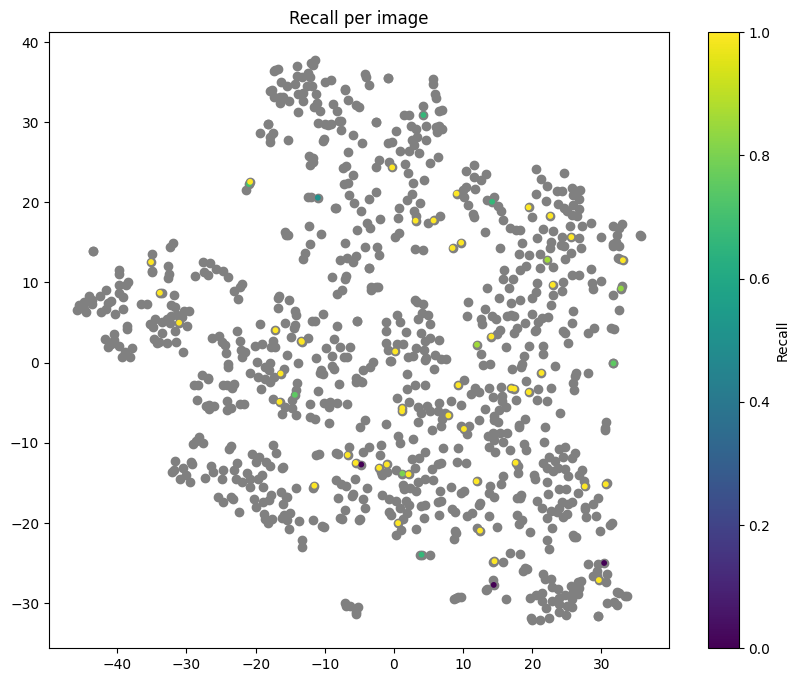

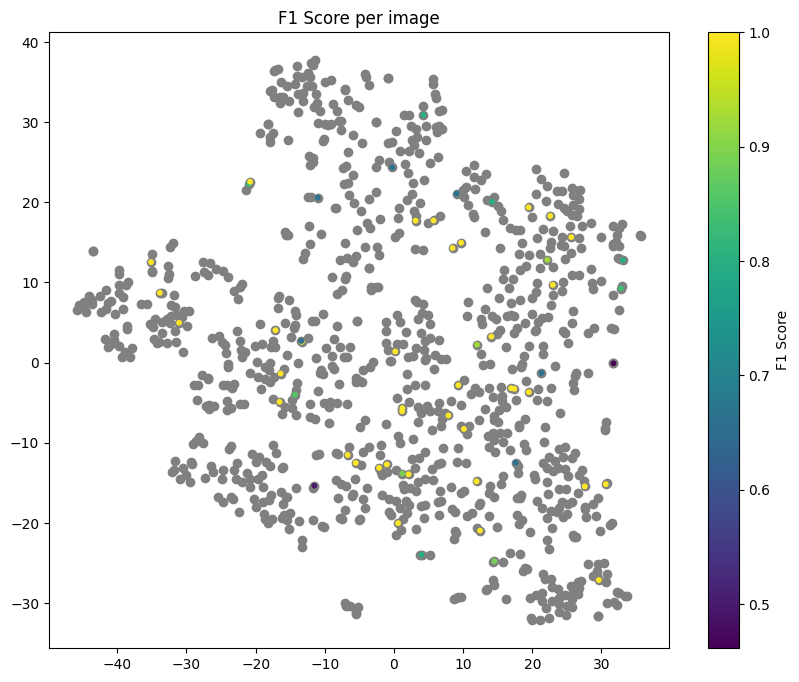

In [253]:
plt.figure(figsize=(10,8))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c="grey")
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=fp_num, cmap='viridis', s=10, vmax=10)
plt.colorbar(label='False positives in image (max 10)')
plt.title("False positives counts")
fig.savefig(os.path.join(out_folder, f'False positives counts.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(10,8))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c="grey")
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=ph_num, cmap='viridis', s=10, vmax=4)
plt.colorbar(label='Pronghorn counts in image (max 4)')
plt.title("Pronghorn counts per image (max 4)")
fig.savefig(os.path.join(out_folder, f'Pronghorn counts per image.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(10,8))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c="grey")
plt.scatter(tsne_embedding[ph_num>0, 0], tsne_embedding[ph_num>0, 1], c='blue', s=10)
plt.scatter(tsne_embedding[fp_num>0, 0], tsne_embedding[fp_num>0, 1], c='red', s=10)
fig.savefig(os.path.join(out_folder, f'Pronghorn and False Positives.png'), dpi=300, bbox_inches='tight')


plt.figure(figsize=(10,8))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c="grey")
plt.scatter(tsne_embedding[ph_num>0, 0], tsne_embedding[ph_num>0, 1], c='blue', s=10)
plt.scatter(tsne_embedding[fp_num>5, 0], tsne_embedding[fp_num>5, 1], c='red', s=10)

plt.title("FP > 5")
fig.savefig(os.path.join(out_folder, f'Pronghorn and High False Positives.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(10,8))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c="grey")
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=precision, cmap='viridis', s=10, vmax=1)
plt.colorbar(label='Precision')
plt.title("Precision per image")
fig.savefig(os.path.join(out_folder, f'Precision per image.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(10,8))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c="grey")
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=recall, cmap='viridis', s=10, vmax=1)
plt.colorbar(label='Recall')
plt.title("Recall per image")
fig.savefig(os.path.join(out_folder, f'Recall per image.png'), dpi=300, bbox_inches='tight')

plt.figure(figsize=(10,8))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c="grey")
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=f1, cmap='viridis', s=10, vmax=1)
plt.colorbar(label='F1 Score')
plt.title("F1 Score per image")
fig.savefig(os.path.join(out_folder, f'F1 Score per image.png'), dpi=300, bbox_inches='tight')

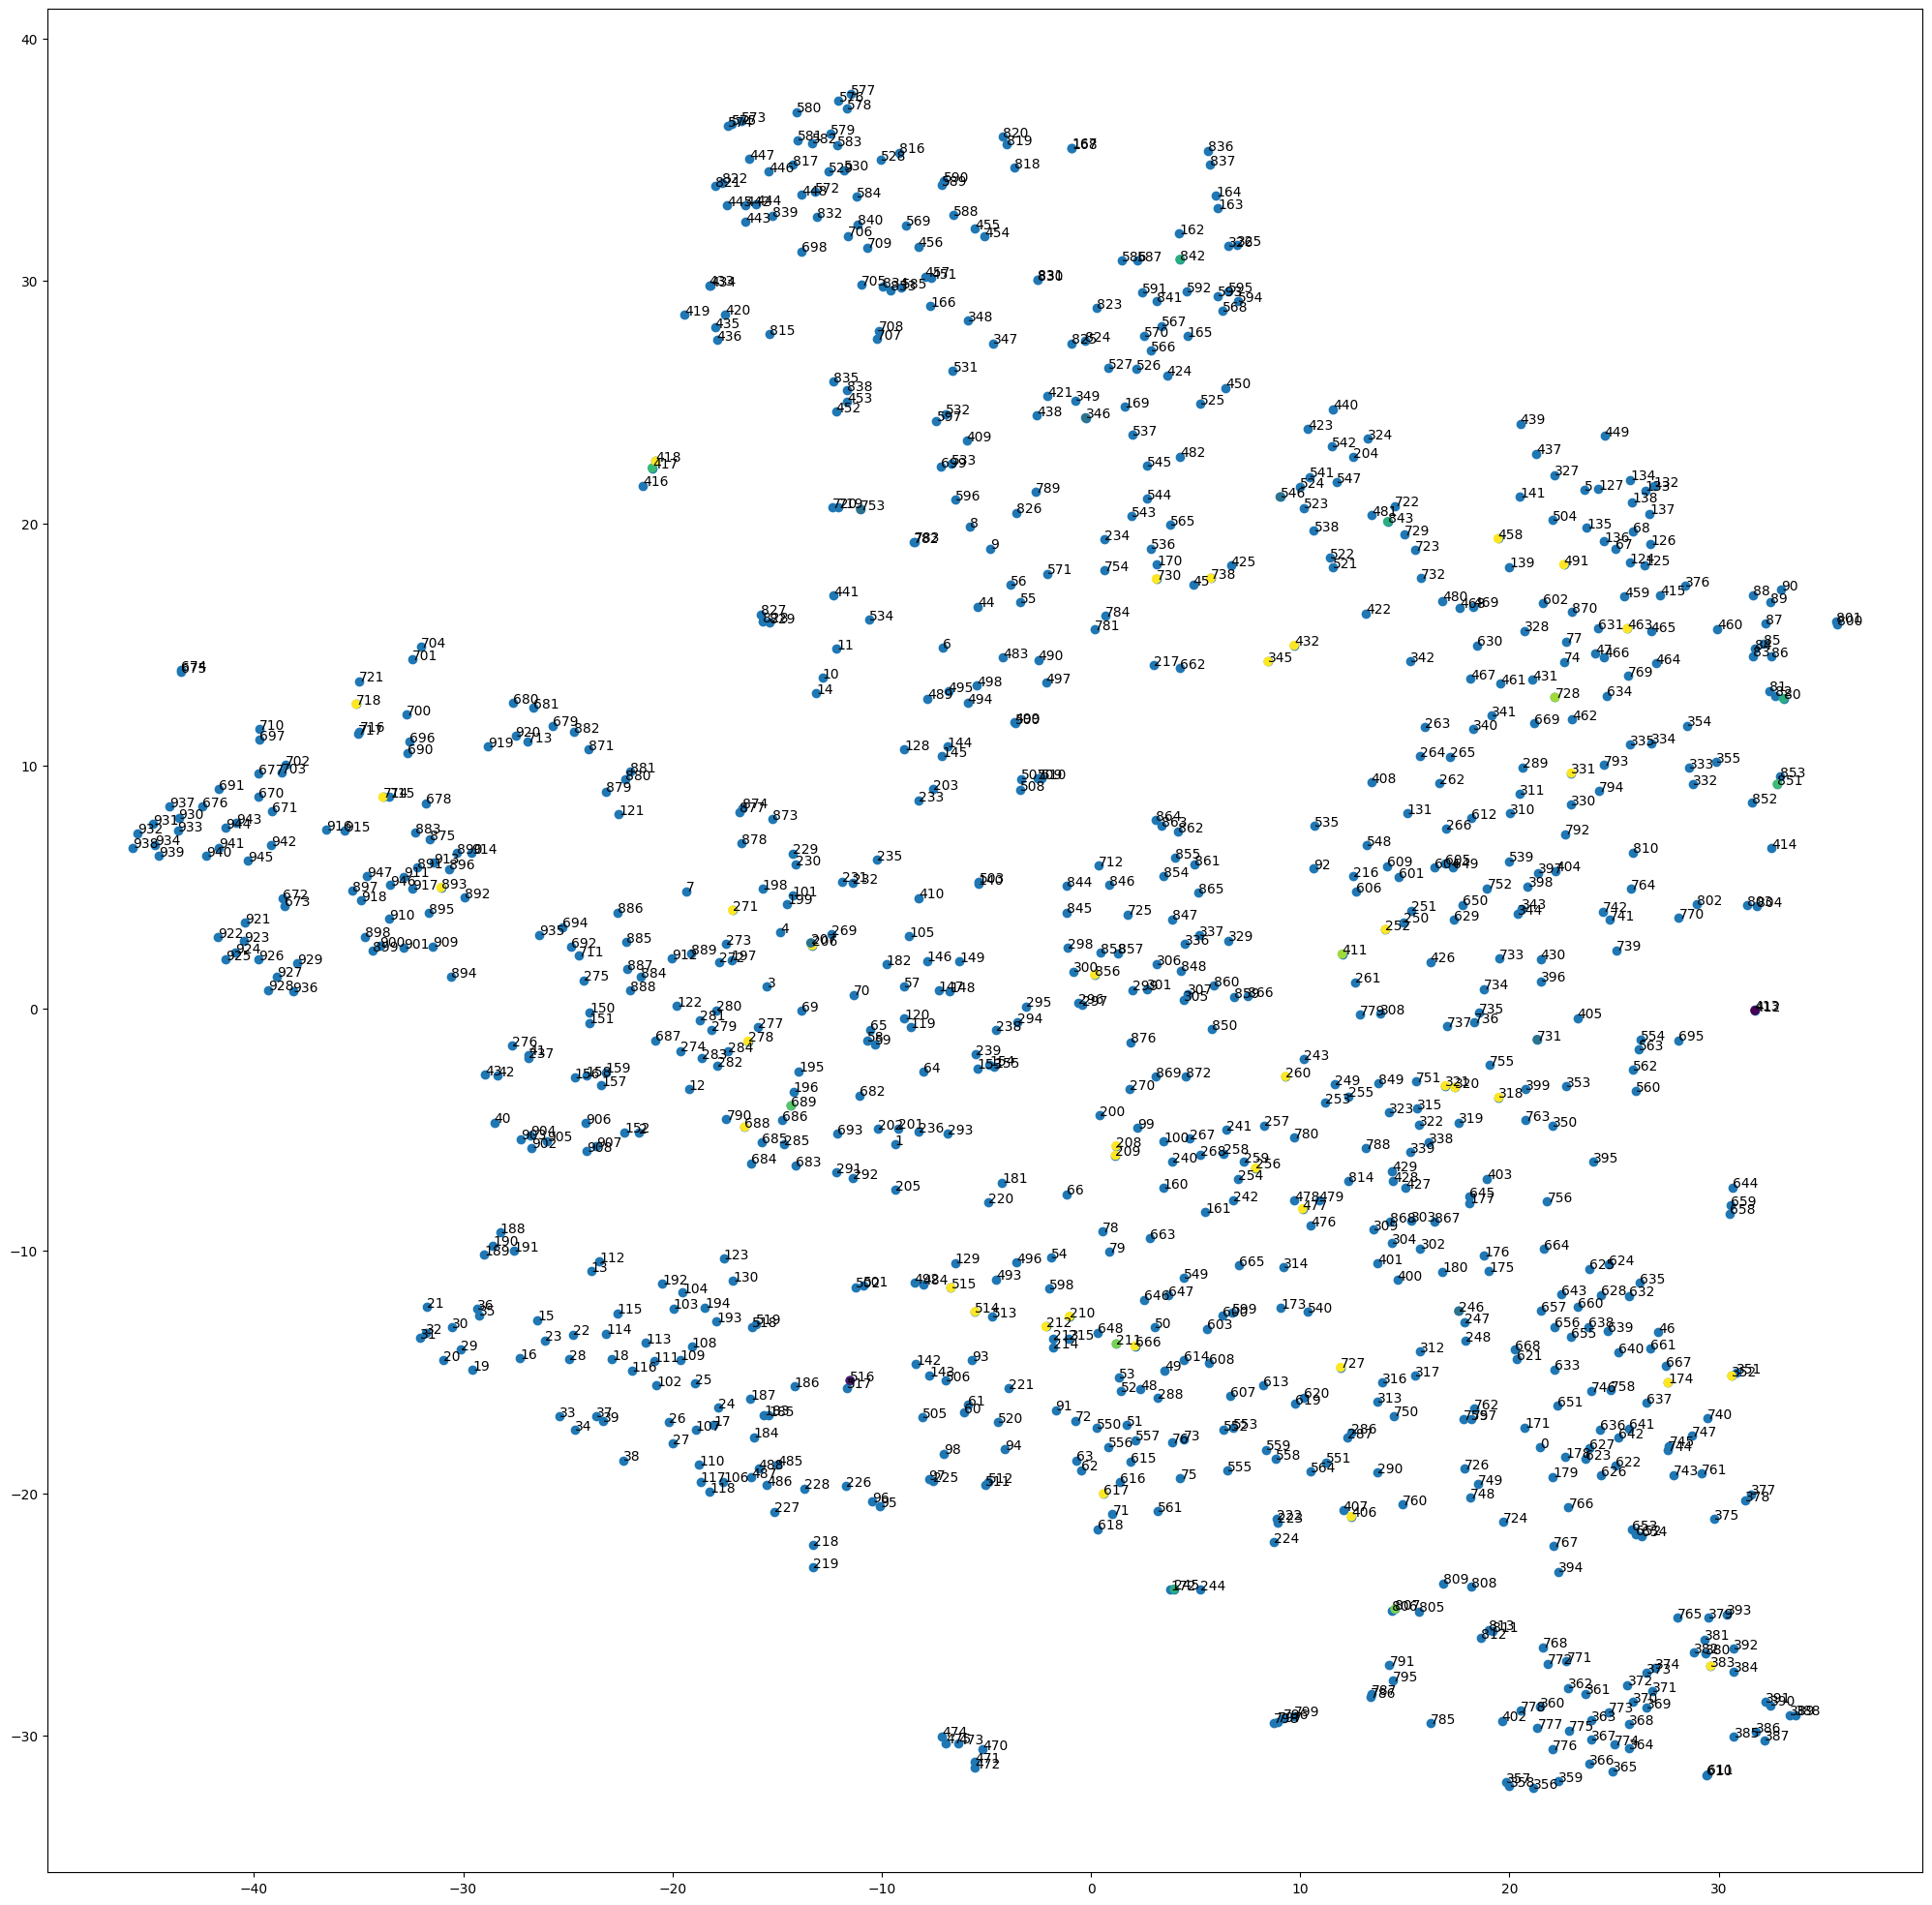

In [205]:
plt.figure(figsize=(25,25))
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1])
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=f1, vmax=1)
for i in range(len(tsne_embedding)):
    plt.annotate(str(i), (tsne_embedding[i, 0], tsne_embedding[i, 1]))

In [208]:
np.array(ph_num)

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  2,  1,  1,  1,  1,  5,  3,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0